In [24]:
import numpy as np
import random
import pandas as pd
from sklearn.datasets import make_classification

In [25]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [26]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.848221,2.116817,0.340357,-1.049650,0.019966,1
1,-2.939136,0.188204,-0.405859,1.355162,0.626610,0
2,0.837424,0.694736,1.521177,-0.509388,-1.668453,1
3,-1.975682,-1.481435,0.319372,0.161831,0.504404,0
4,1.811609,0.830320,1.167972,-1.133174,-0.025780,1


In [27]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [28]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [29]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [30]:
df1 = combined_sampling(df,0.5,0.5)

In [31]:
df2 = combined_sampling(df,0.5,0.5)

In [32]:
df3 = combined_sampling(df,0.5,0.5)

In [33]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col3', 'target'], dtype='str')
Index(['col5', 'col2', 'target'], dtype='str')
Index(['col1', 'col2', 'target'], dtype='str')


In [34]:
df3

,col1,col2,target
34,1.421057,1.614855,1
30,2.589449,2.012013,1
4,1.811609,0.830320,1
66,-0.453979,-0.734566,0
93,-1.166471,0.294178,1
57,-0.865915,-1.001067,0
51,-1.075596,-2.401337,0
62,-0.165962,-0.567068,0
55,-1.314779,-0.073785,1
26,0.185174,-0.097831,0


In [35]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [36]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
from sklearn.tree import plot_tree

[Text(0.4090909090909091, 0.9166666666666666, 'x[0] <= -0.519\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.18181818181818182, 0.75, 'x[1] <= 2.776\ngini = 0.165\nsamples = 22\nvalue = [20, 2]'),
 Text(0.29545454545454547, 0.8333333333333333, 'True  '),
 Text(0.09090909090909091, 0.5833333333333334, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.2727272727272727, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6363636363636364, 0.75, 'x[0] <= 0.214\ngini = 0.293\nsamples = 28\nvalue = [5, 23]'),
 Text(0.5227272727272727, 0.8333333333333333, '  False'),
 Text(0.45454545454545453, 0.5833333333333334, 'x[1] <= 2.337\ngini = 0.494\nsamples = 9\nvalue = [4, 5]'),
 Text(0.36363636363636365, 0.4166666666666667, 'x[0] <= -0.208\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2727272727272727, 0.25, 'x[0] <= -0.313\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.18181818181818182, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 

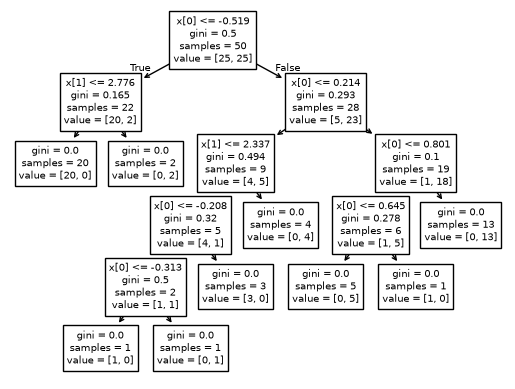

In [38]:
plot_tree(clf1)

[Text(0.5, 0.9166666666666666, 'x[1] <= 0.254\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.25, 0.75, 'x[0] <= -1.425\ngini = 0.312\nsamples = 31\nvalue = [25, 6]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.375, 0.5833333333333334, 'x[1] <= -0.96\ngini = 0.137\nsamples = 27\nvalue = [25, 2]'),
 Text(0.25, 0.4166666666666667, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.5, 0.4166666666666667, 'x[0] <= 0.84\ngini = 0.298\nsamples = 11\nvalue = [9, 2]'),
 Text(0.375, 0.25, 'x[0] <= -0.556\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.25, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.625, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.75, 0.75, 'x[0] <= 1.862\ngini = 0.1\nsamples = 19\nvalue = [1, 18]'),
 Text(0.625, 0.8333333333333333, '  False'),
 Text(0.625, 0.

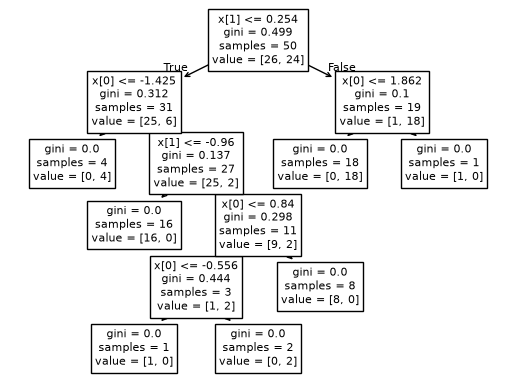

In [39]:
plot_tree(clf2)

[Text(0.5555555555555556, 0.9285714285714286, 'x[1] <= 0.241\ngini = 0.48\nsamples = 50\nvalue = [30, 20]'),
 Text(0.3333333333333333, 0.7857142857142857, 'x[0] <= 1.685\ngini = 0.213\nsamples = 33\nvalue = [29, 4]'),
 Text(0.4444444444444444, 0.8571428571428572, 'True  '),
 Text(0.2222222222222222, 0.6428571428571429, 'x[1] <= -0.612\ngini = 0.121\nsamples = 31\nvalue = [29, 2]'),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= -0.584\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.2222222222222222, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.35714285714285715, 'x[0] <= -1.077\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.3333333333333333, 0.21428571428571427, 'x[0] <= -2.127\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.071428571428571

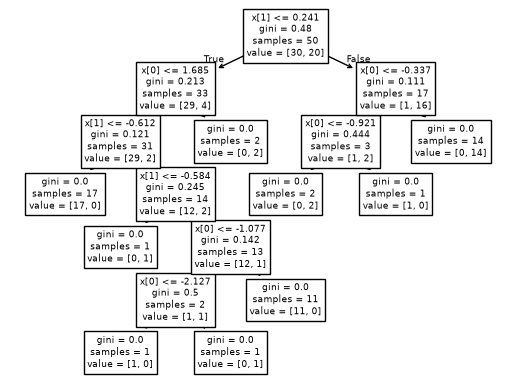

In [40]:
plot_tree(clf3)

In [41]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [42]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [43]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [44]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
33,0.128813,-0.027089,2.038998,-0.018151,-1.873716,1
75,0.879118,1.392503,0.261438,-0.325576,-0.757140,1
37,-1.053988,-2.288108,0.913415,-0.236911,1.503616,0
37,-1.053988,-2.288108,0.913415,-0.236911,1.503616,0
73,-2.161157,-2.525596,0.745860,-1.518323,1.247751,0
99,1.263034,0.440159,1.273241,-0.982661,-0.041720,1
47,0.477639,0.533803,1.395397,-1.939501,-0.752815,1
52,-0.002803,-0.366136,2.293216,1.958692,2.292247,0
62,-0.165962,-0.567068,2.060189,1.334966,0.633155,0
11,0.839259,0.017642,2.215774,3.099721,1.914638,0
